# 2026 高教社杯 C 题 · 问题三预测与优化（唯一最终版）

**含日内预报更新的微网四阶段购电策略**

本版统一修复以下口径：

1. 1月1—10日只作预测预热；所有新增参数统一使用 **2025年1月11—31日** 选择，2—12月仅用于部署和事后评价。
2. 0:00、6:00、12:00、18:00 每个阶段都优化未来 **严格48小时**。
3. 附件3发布后的完整24小时预报按绝对目标时刻使用，跨日部分不再丢弃。
4. 48小时全窗口均加入历史残差经验分位数安全余量。
5. $[Q_{\alpha_{lo}},Q_{\alpha_{hi}}]$ 是由单时段边际分析启发的净负荷供电目标不调整带；参数由一月滚动验证确定。
6. 每阶段比较上一阶段当前生效的净负荷供电目标与最新分位带；若当日剩余时段全部在带内则跳过调整，否则裁剪目标并重解含储能耦合的线性规划。
7. 问题2基准由最终同口径代码重算；所有费用由当前运行结果生成，不再手工填写。

运行只需要官方附件1、附件2、附件3及 `result3.xlsx` 模板。代码会在本目录和已知官方附件目录中自动查找。

## 1 信息边界与参数来源

- **与问题二一致**：小区负荷预测、光伏历史预测、机会约束、储能模型、SOC连续传递和紧急购电结算。
- **问题三新增**：附件3时间对齐与降尺度、卡尔曼预报融合、0:00计划分位数、净负荷供电目标不调整带和四阶段调整。
- **选择期**：1月11—31日；1月1—10日只作预测预热。
- **部署期**：2月1—12月31日。新增参数在2月1日前冻结，后续真值只在揭晓后进入滚动历史。

> Notebook保留问题二基础函数是为了能够独立运行，论文正文不重复展开问题二模型。

In [1]:
from __future__ import annotations

from functools import lru_cache
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.sparse import csr_matrix, lil_matrix

# ---------- constants ----------
T, DT = 144, 1 / 6
START = 31
SELECT_DAYS = range(10, START)
ISSUE = [0, 6, 12, 18]
STAGE_SLOT = [0, 36, 72, 108]
ETA, R_MAX, SMIN, SMAX = 0.9, 5000 / 6, 1200.0, 10800.0
PEN, UP, DN = 5.0, 1.5, 0.5
EW_N, EW_DECAY, RESID_LOOK, FUSER_LOOK = 8, 0.6, 14, 14
DAY0 = pd.Timestamp("2025-01-01")


def resolve_file(name: str, candidates: list[str]) -> Path:
    for raw in candidates:
        p = Path(raw)
        if p.exists():
            return p
    raise FileNotFoundError(f"找不到 {name}；已检查：{candidates}")


DATA1 = resolve_file("附件1.xlsx", [
    "附件1.xlsx", r"C:\Users\12055\Desktop\2026 国赛\附件1.xlsx",
    r"C:\Users\12055\Desktop\Hermes\2026国赛C题\official\extracted\C题\附件\附件1.xlsx",
])
DATA2 = resolve_file("附件2.xlsx", [
    "附件2.xlsx", r"C:\Users\12055\Desktop\2026 国赛\附件2.xlsx",
    r"C:\Users\12055\Desktop\Hermes\2026国赛C题\official\extracted\C题\附件\附件2.xlsx",
])
DATA3 = resolve_file("附件3.xlsx", [
    "附件3.xlsx", r"C:\Users\12055\Desktop\2026 国赛\附件3.xlsx",
    r"C:\Users\12055\Desktop\Hermes\2026国赛C题\official\extracted\C题\附件\附件3.xlsx",
])
RESULT3_TEMPLATE = resolve_file("result3.xlsx", [
    "result3.xlsx", r"C:\Users\12055\Desktop\2026 国赛\附件5\result3.xlsx",
    r"C:\Users\12055\Desktop\Hermes\2026国赛C题\official\extracted\C题\附件\附件5\result3.xlsx",
])

price = pd.read_excel(DATA1)["电价"].to_numpy(float)
Ld = pd.read_excel(DATA2, sheet_name="小区负载")
L = Ld.iloc[:, 1:].to_numpy(float)
Gv = pd.read_excel(DATA2, sheet_name="光伏发电实际功率").iloc[:, 1:].to_numpy(float)
dates = pd.DatetimeIndex(pd.to_datetime(Ld.iloc[:, 0]))
ND = len(dates)
assert L.shape == Gv.shape == (365, T)
assert len(price) == T

F = pd.read_excel(DATA3)
F["日期"] = pd.to_datetime(F["日期"].ffill())
F["h0"] = F["预报时刻"].astype(str).str.split(":").str[0].astype(int)
FC = np.full((ND, 4, 25), np.nan)
for _, row in F.iterrows():
    d = (row["日期"] - DAY0).days
    if 0 <= d < ND:
        k = ISSUE.index(int(row["h0"]))
        for h in range(1, 25):
            FC[d, k, h] = float(row[f"预报{h}小时"])

Lflat, Gflat = L.ravel(), Gv.ravel()


def low_type(target_day: int) -> bool:
    return (DAY0 + pd.Timedelta(days=int(target_day))).dayofweek in (4, 5)


@lru_cache(None)
def ew_load_day(cutoff: int, target_day: int) -> np.ndarray:
    idx = [j for j in range(cutoff - 1, -1, -1) if low_type(j) == low_type(target_day)][:EW_N]
    w = EW_DECAY ** np.arange(len(idx)); w /= w.sum()
    return np.sum(w[:, None] * L[idx], axis=0)


@lru_cache(None)
def ew_pv_day(cutoff: int, target_day: int) -> np.ndarray:
    idx = list(range(cutoff - 1, max(-1, cutoff - EW_N - 1), -1))
    w = EW_DECAY ** np.arange(len(idx)); w /= w.sum()
    pred = np.sum(w[:, None] * Gv[idx], axis=0)
    pred[Gv[:cutoff].max(axis=0) <= 0] = 0
    return np.maximum(pred, 0)


def ew_abs(kind: str, cutoff: int, abs_slots: np.ndarray) -> np.ndarray:
    out = np.empty(len(abs_slots), float)
    for td in np.unique(abs_slots // T):
        m = abs_slots // T == td
        day_pred = ew_load_day(cutoff, int(td)) if kind == "load" else ew_pv_day(cutoff, int(td))
        out[m] = day_pred[abs_slots[m] % T]
    return out


def downscale_24h(d: int, k: int, method: str = "linear") -> tuple[np.ndarray, np.ndarray]:
    """保留发布后完整24小时；返回绝对目标时段及10分钟预报。"""
    release = d * T + STAGE_SLOT[k]
    x = np.arange(release, release + T)  # release + T 明确跨日保留
    anchors = release + 6 * np.arange(1, 25) - 1
    vals = FC[d, k, 1:25].astype(float)
    prev = Gflat[release - 1] if release > 0 else 0.0
    if method == "linear":
        out = np.interp(x, np.r_[release - 1, anchors], np.r_[prev, vals])
    elif method == "hold":
        out = np.repeat(vals, 6)
    elif method == "shape":
        base = ew_abs("pv", d, x)
        out = np.interp(x, np.r_[release - 1, anchors], np.r_[prev, vals])
        for pos, value in zip(anchors, vals):
            m = (x >= pos - 5) & (x <= pos)
            seg = base[m]
            if len(seg) and seg[-1] > 1e-6:
                out[m] = value * seg / seg[-1]
    else:
        raise ValueError(method)
    return x, np.maximum(out, 0)


def january_alignment_table() -> pd.DataFrame:
    rows = []
    hourly = Gv.reshape(ND, 24, 6).mean(2).ravel()
    for mode in ("小时均值", "小时末瞬时", "小时初瞬时"):
        for off in (0, -1):
            err = []
            for d in SELECT_DAYS:
                for k, h0 in enumerate(ISSUE):
                    for h in range(1, 25):
                        hour_abs = d * 24 + h0 + h + off
                        if mode == "小时均值":
                            if 0 <= hour_abs < START * 24:
                                err.append(FC[d, k, h] - hourly[hour_abs])
                        else:
                            slot_abs = hour_abs * 6 - (1 if mode == "小时末瞬时" else 0)
                            if 0 <= slot_abs < START * T:
                                err.append(FC[d, k, h] - Gflat[slot_abs])
            rows.append({"对齐方式": mode, "偏移": off, "一月MAE/kW": np.mean(np.abs(err))})
    return pd.DataFrame(rows).sort_values("一月MAE/kW").reset_index(drop=True)


def january_downscale_table() -> pd.DataFrame:
    rows = []
    for method in ("hold", "linear", "shape"):
        err = []
        for d in SELECT_DAYS:
            for k in range(4):
                pos, pred = downscale_24h(d, k, method)
                m = pos < START * T
                act = Gflat[pos[m]]; p = pred[m]
                daylight = (act > 50) | (p > 50)
                if daylight.any(): err.extend(p[daylight] - act[daylight])
        e = np.asarray(err)
        rows.append({"方法": method, "一月MAE/kW": np.abs(e).mean(), "一月RMSE/kW": np.sqrt(np.mean(e**2))})
    return pd.DataFrame(rows).sort_values("一月MAE/kW").reset_index(drop=True)


# 方法只由一月选择；在后续期冻结。
ALIGNMENT_TABLE = january_alignment_table()
DOWNSCALE_TABLE = january_downscale_table()
SELECTED_DOWNSCALE = str(DOWNSCALE_TABLE.iloc[0]["方法"])
FC10 = np.full((ND, 4, T), np.nan)
for d in range(ND):
    for k in range(4):
        FC10[d, k] = downscale_24h(d, k, SELECTED_DOWNSCALE)[1]


@lru_cache(None)
def point_forecast48(d: int, k: int, use_attachment: bool = True) -> np.ndarray:
    """决策时刻起严格48小时净负荷点预测，只用d日前真值与当时已发布预报。"""
    release = d * T + STAGE_SLOT[k]
    abs_slots = np.arange(release, release + 2 * T)
    load_hat = ew_abs("load", d, abs_slots)
    pv_ew = ew_abs("pv", d, abs_slots)
    pv_hat = pv_ew.copy()
    if use_attachment:
        for r in range(T):
            target = release + r
            if target >= len(Gflat) + T:
                continue
            efc, eew = [], []
            for j in range(d - 1, max(7, d - FUSER_LOOK - 3), -1):
                hist_target = j * T + STAGE_SLOT[k] + r
                if hist_target >= release or hist_target >= len(Gflat):
                    continue
                f = FC10[j, k, r]
                if not np.isfinite(f):
                    continue
                actual = Gflat[hist_target]
                ew0 = ew_abs("pv", j, np.array([hist_target]))[0]
                if actual > 50 or f > 50:
                    efc.append(f - actual); eew.append(ew0 - actual)
                if len(efc) >= FUSER_LOOK:
                    break
            fcur = FC10[d, k, r]
            if len(efc) < 5:
                pv_hat[r] = 0.5 * fcur + 0.5 * pv_ew[r]
            else:
                efc = np.asarray(efc); eew = np.asarray(eew)
                bias = efc.mean(); vfc = max(efc.var(), 1.0); vew = max(eew.var(), 1.0)
                fcur -= bias
                pv_hat[r] = ((1 / vfc) * fcur + (1 / vew) * pv_ew[r]) / ((1 / vfc) + (1 / vew))
    return (load_hat - np.maximum(pv_hat, 0)) * DT


@lru_cache(None)
def residual_samples48(d: int, k: int, look: int = RESID_LOOK) -> np.ndarray:
    """每个相对时段取最近look个、在当前发布时刻前已揭晓的残差。"""
    release = d * T + STAGE_SLOT[k]
    samples = np.full((look, 2 * T), np.nan)
    for r in range(2 * T):
        vals = []
        for j in range(d - 1, 7, -1):
            target = j * T + STAGE_SLOT[k] + r
            if target >= release or target >= len(Gflat):
                continue
            vals.append((Lflat[target] - Gflat[target]) * DT - point_forecast48(j, k)[r])
            if len(vals) == look:
                break
        if vals:
            samples[:len(vals), r] = vals
    return samples


def rho48(d: int, k: int, alpha: float, look: int = RESID_LOOK) -> np.ndarray:
    """严格48小时全窗的经验分位数余量；今天、明天及跨日部分均不遗漏。"""
    s = residual_samples48(d, k, look)
    out = np.nanquantile(s, alpha, axis=0)
    return np.nan_to_num(out, nan=0.0)


def solve_stage48(d: int, k: int, target48: np.ndarray, S0: float,
                  qplan: np.ndarray | None = None) -> np.ndarray:
    """每个阶段严格优化未来48小时，只执行到当日24:00。"""
    H = 2 * T
    target48 = np.asarray(target48, float)
    if target48.shape != (H,):
        raise ValueError("target48必须恰为288个10分钟时段")
    t0 = STAGE_SLOT[k]; n_exec = T - t0
    abs_slots = d * T + t0 + np.arange(H)
    ph = price[abs_slots % T]
    nv = 4 * H + (n_exec if qplan is not None else 0)
    iq, ic, iu, iS = (np.arange(H) + j * H for j in range(4))
    cobj = np.zeros(nv)
    if qplan is None:
        cobj[iq] = ph
    else:
        cobj[iq[n_exec:]] = ph[n_exec:]
        iy = 4 * H + np.arange(n_exec); cobj[iy] = 1.0
    lb = np.zeros(nv); ub = np.full(nv, np.inf)
    lb[iS] = SMIN; ub[iS] = SMAX
    if qplan is not None:
        lb[iy] = -np.inf
    rows, cols, vals, rhs = [], [], [], []; rr = 0; tt = np.arange(H)
    rows += [rr + tt, rr + tt, rr + tt]; cols += [iq, iu, ic]
    vals += [-np.ones(H), -np.ones(H), np.ones(H)]; rhs.append(-target48); rr += H
    rows += [rr + tt, rr + tt]; cols += [ic, iu]
    vals += [np.ones(H), np.ones(H)]; rhs.append(np.full(H, R_MAX)); rr += H
    if qplan is not None:
        pd0 = price[t0:]
        for coef in (DN, UP):
            r0 = rr + np.arange(n_exec)
            rows += [r0, r0]; cols += [iq[:n_exec], iy]
            vals += [coef * pd0, -np.ones(n_exec)]
            rhs.append(coef * pd0 * qplan[t0:]); rr += n_exec
    A_ub = csr_matrix((np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))), shape=(rr, nv))
    er = [tt, tt[1:], tt, tt]; ec = [iS, iS[:-1], ic, iu]
    ev = [np.ones(H), -np.ones(H - 1), -ETA * np.ones(H), np.ones(H) / ETA]
    A_eq = csr_matrix((np.concatenate(ev), (np.concatenate(er), np.concatenate(ec))), shape=(H, nv))
    b_eq = np.zeros(H); b_eq[0] = S0
    res = linprog(cobj, A_ub=A_ub, b_ub=np.concatenate(rhs), A_eq=A_eq, b_eq=b_eq,
                  bounds=np.c_[lb, ub], method="highs")
    if not res.success:
        raise RuntimeError(f"{dates[min(d, ND-1)].date()} 阶段{k} LP失败：{res.message}")
    return res.x[iq[:n_exec]]


def settle(q: np.ndarray, net_act: np.ndarray, S0: float):
    n = len(q); c = np.zeros(n); u = np.zeros(n); e = np.zeros(n); w = np.zeros(n); S = np.zeros(n); s = float(S0)
    for t in range(n):
        gap = net_act[t] - q[t]
        if gap > 0:
            u[t] = min(gap, R_MAX, (s - SMIN) * ETA); e[t] = gap - u[t]; s -= u[t] / ETA
        else:
            c[t] = min(-gap, R_MAX, (SMAX - s) / ETA); w[t] = -gap - c[t]; s += ETA * c[t]
        S[t] = s
    return c, u, e, w, S


def state_at(q: np.ndarray, net_act: np.ndarray, S0: float, t0: int) -> float:
    if t0 == 0:
        return S0
    return float(settle(q[:t0], net_act[:t0], S0)[4][-1])


def simulate(stages=(1, 2, 3), A0=0.7, ALO=0.7, AHI=0.9,
             S_init=6000.0, days=None, use_attachment=True):
    days = list(range(START, ND) if days is None else days)
    if not days or days != list(range(days[0], days[-1] + 1)):
        raise ValueError("days必须为非空连续日期范围")
    rec = {k: [] for k in ["qplan", "qadj", "c", "u", "e", "w", "S", "S0"]}
    s = float(S_init)
    for d in days:
        q = np.zeros(T)
        pred0 = point_forecast48(d, 0, use_attachment)
        target0 = pred0 + rho48(d, 0, A0)
        q[:] = solve_stage48(d, 0, target0, s)
        qplan = q.copy(); current_target_day = target0[:T].copy()
        for k in stages:
            t0 = STAGE_SLOT[k]; n_exec = T - t0
            pred = point_forecast48(d, k, use_attachment)
            lo = pred + rho48(d, k, ALO)
            hi = pred + rho48(d, k, AHI)
            # 比较上一阶段当前生效的净负荷供电目标；全部在带内则不调整。
            base = current_target_day[t0:]
            inside_band = (base >= lo[:n_exec]) & (base <= hi[:n_exec])
            if np.all(inside_band):
                continue
            target48 = pred + rho48(d, k, A0)  # 明天及整个48小时同样带安全余量
            target48[:n_exec] = np.clip(base, lo[:n_exec], hi[:n_exec])
            s_now = state_at(q, (L[d] - Gv[d]) * DT, s, t0)
            q[t0:] = solve_stage48(d, k, target48, s_now, qplan)
            current_target_day[t0:] = target48[:n_exec]
        c, u, e, w, S = settle(q, (L[d] - Gv[d]) * DT, s)
        for key, value in zip(["qplan", "qadj", "c", "u", "e", "w", "S"], [qplan, q, c, u, e, w, S]):
            rec[key].append(value)
        rec["S0"].append(s); s = float(S[-1])
    return {k: np.asarray(v) for k, v in rec.items()}


def cost(rec: dict[str, np.ndarray]) -> dict[str, float]:
    P = price[None, :]; qp, qa, e = rec["qplan"], rec["qadj"], rec["e"]
    plan = np.sum(qp * P); up = np.sum(UP * P * np.maximum(qa - qp, 0))
    dn = np.sum(DN * P * np.maximum(qp - qa, 0)); emg = np.sum(PEN * P * e)
    return {"计划购电费/万元": plan / 1e4, "调增费/万元": up / 1e4,
            "调减退费/万元": -dn / 1e4, "紧急购电费/万元": emg / 1e4,
            "总费用/万元": (plan + up - dn + emg) / 1e4,
            "紧急购电量/万kWh": e.sum() / 1e4,
            "发生紧急购电天数": int(np.sum(e.sum(axis=1) > 1e-6))}


def select_parameters_january(a0_values=(0.6, 0.7, 0.8, 0.9),
                              bands=((0.5, 0.99), (0.6, 0.95), (0.7, 0.9), (0.75, 0.85))):
    rows = []
    for a0 in a0_values:
        for lo, hi in bands:
            rec = simulate(A0=a0, ALO=lo, AHI=hi, days=SELECT_DAYS)
            rows.append({"A0": a0, "ALO": lo, "AHI": hi, **cost(rec)})
    table = pd.DataFrame(rows).sort_values(["总费用/万元", "A0", "ALO"]).reset_index(drop=True)
    best = table.iloc[0]
    return table, {"A0": float(best.A0), "ALO": float(best.ALO), "AHI": float(best.AHI)}


# ---------- Q2 exact baseline: copied specification from final Q2 ----------
def solve_plan_lp(load_energy, pv_energy, price48, s0):
    h = 2 * T; nv = 6 * h
    eu, es, qu, qs, v, soc = [np.arange(h) + k * h for k in range(6)]
    cobj = np.zeros(nv); cobj[qu] = price48; cobj[qs] = price48
    bounds = [(0, None)] * (5 * h) + [(SMIN, SMAX)] * h
    aub = lil_matrix((2 * h, nv)); bub = np.r_[pv_energy, np.full(h, R_MAX)]
    for t in range(h):
        aub[t, eu[t]] = 1; aub[t, es[t]] = 1
        aub[h + t, es[t]] = 1; aub[h + t, qs[t]] = 1; aub[h + t, v[t]] = 1
    aeq = lil_matrix((2 * h, nv)); beq = np.r_[load_energy, s0, np.zeros(h - 1)]
    for t in range(h):
        aeq[t, eu[t]] = 1; aeq[t, qu[t]] = 1; aeq[t, v[t]] = 1
        r = h + t; aeq[r, soc[t]] = 1; aeq[r, es[t]] = -ETA; aeq[r, qs[t]] = -ETA; aeq[r, v[t]] = 1 / ETA
        if t > 0: aeq[r, soc[t - 1]] = -1
    res = linprog(cobj, A_ub=aub.tocsr(), b_ub=bub, A_eq=aeq.tocsr(), b_eq=beq,
                  bounds=bounds, method="highs")
    if not res.success: raise RuntimeError(res.message)
    return res.x[qu][:T] + res.x[qs][:T]


def simulate_q2_baseline(alpha=0.8, look=14, S_init=6000.0):
    hist = []
    for d in range(10, START):
        pred = (ew_load_day(d, d) - ew_pv_day(d, d)) * DT
        hist.append((L[d] - Gv[d]) * DT - pred)
    qrows, erows, s = [], [], float(S_init)
    price48 = np.r_[price, price]
    for d in range(START, ND):
        rho = np.quantile(np.asarray(hist[-look:]), alpha, axis=0)
        l48 = np.r_[ew_load_day(d, d), ew_load_day(d, d + 1)] * DT + np.r_[rho, rho]
        p48 = np.r_[ew_pv_day(d, d), ew_pv_day(d, d + 1)] * DT
        q = solve_plan_lp(l48, p48, price48, s)
        _, _, e, _, S = settle(q, (L[d] - Gv[d]) * DT, s); s = float(S[-1])
        pred = (ew_load_day(d, d) - ew_pv_day(d, d)) * DT
        hist.append((L[d] - Gv[d]) * DT - pred); hist = hist[-60:]
        qrows.append(q); erows.append(e)
    rec = {"qplan": np.asarray(qrows), "qadj": np.asarray(qrows), "e": np.asarray(erows)}
    return rec, cost(rec)


In [2]:
print(f"负荷/光伏：{ND}天 × {T}时段；部署期 {dates[START].date()}—{dates[-1].date()}，共{ND-START}天")
print("读取文件：", DATA1, DATA2, DATA3, sep="\n- ")
print("\n一月时间对齐比较：")
display(ALIGNMENT_TABLE)
print("\n一月降尺度比较：")
display(DOWNSCALE_TABLE)
print(f"冻结选择：小时末瞬时、偏移0；降尺度={SELECTED_DOWNSCALE}")

负荷/光伏：365天 × 144时段；部署期 2025-02-01—2025-12-31，共334天
读取文件：
- C:\Users\12055\Desktop\2026 国赛\附件1.xlsx
- C:\Users\12055\Desktop\2026 国赛\附件2.xlsx
- C:\Users\12055\Desktop\2026 国赛\附件3.xlsx

一月时间对齐比较：


,对齐方式,偏移,一月MAE/kW
0,小时末瞬时,0,127.550574
1,小时初瞬时,0,180.128429
2,小时均值,-1,258.978924
3,小时均值,0,358.569770
4,小时初瞬时,-1,454.483782
5,小时末瞬时,-1,536.309608



一月降尺度比较：


,方法,一月MAE/kW,一月RMSE/kW
0,linear,285.128810,432.051971
1,shape,337.730154,502.843105
2,hold,596.020810,777.881985


冻结选择：小时末瞬时、偏移0；降尺度=linear


## 4 预测层：用卡尔曼滤波融合历史规律与附件3

### 4.1 为什么需要融合

问题二的历史预测能够描述稳定日型，但难以及时反映当天云层变化；附件3包含实时天气信息，却可能在长提前期出现较大偏差。固定选择任一信息源都不稳妥，因此将问题二预测视为先验、附件3视为新观测。

### 4.2 卡尔曼更新

先根据过去已经完成的日期估计附件3的滚动偏差，并对当前预报去偏：

$$
\tilde G^{\mathrm F}_{d,k,t}=\hat G^{\mathrm F}_{d,k,t}-\hat b_{d,k,t}.
$$

记问题二历史预测误差方差为$P_{d,k,t}$，附件3误差方差为$R_{d,k,t}$，则

$$
K_{d,k,t}=\frac{P_{d,k,t}}{P_{d,k,t}+R_{d,k,t}},
$$

$$
\hat G_{d,k,t}=\hat G^{\mathrm{EW}}_{d,t}
+K_{d,k,t}\left(\tilde G^{\mathrm F}_{d,k,t}-\hat G^{\mathrm{EW}}_{d,t}\right).
$$

$K$接近1时更信任附件3，接近0时更信任历史预测。偏差和方差只使用当前发布时间以前已经揭晓的误差；有效历史少于5个样本时暂用相同权重。附件3覆盖前24小时，48小时窗口的后24小时继续使用历史预测。

一月两类预测误差：


,附件3 MAE/kW,历史预测 MAE/kW
发布时刻,,
0:00,275.157687,196.223794
12:00,279.967966,195.791165
18:00,391.139279,201.022227
6:00,193.957573,196.351277


一月各发布时刻的平均卡尔曼增益：


,平均K
发布时刻,
0:00,0.319723
12:00,0.370893
18:00,0.176274
6:00,0.467606


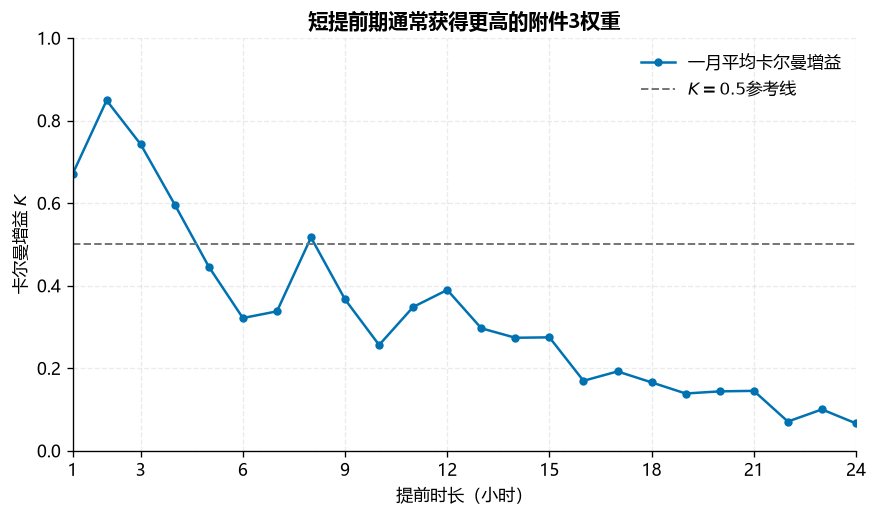

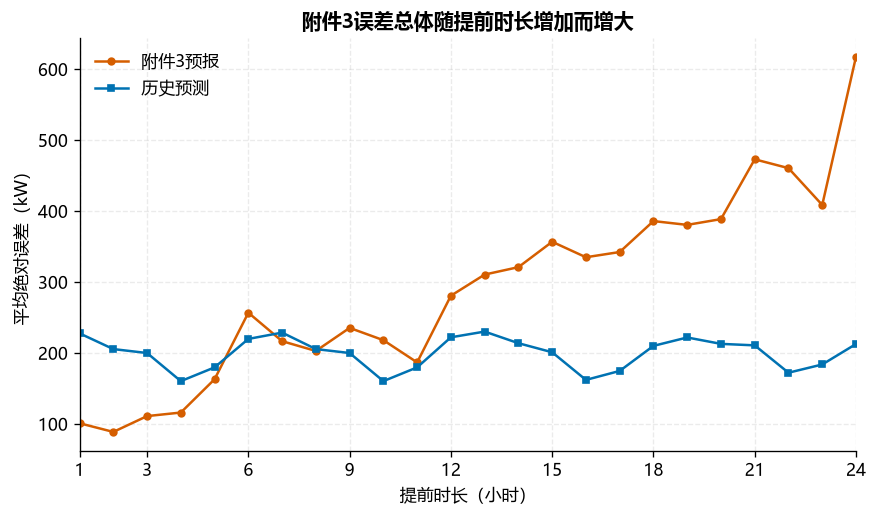

In [3]:
# 只用一月选择期检查两类预测误差、提前时长效应与滚动卡尔曼增益
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import font_manager

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
cn_font = next((x for x in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC"] if x in available_fonts), "DejaVu Sans")
plt.rcParams.update({
    "font.sans-serif": [cn_font, "DejaVu Sans"], "axes.unicode_minus": False,
    "figure.dpi": 120, "savefig.dpi": 300, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25,
    "grid.linestyle": "--", "axes.titleweight": "bold"
})
FIG_DIR = Path("图表")
FIG_DIR.mkdir(exist_ok=True)

forecast_rows, gain_rows, lead_error_rows = [], [], []
for d in SELECT_DAYS:
    for k in range(4):
        release = d*T + STAGE_SLOT[k]
        pos = release + np.arange(T)
        valid = pos < START*T
        act = Gflat[pos[valid]]
        fc = FC10[d, k, :][valid]
        ew0 = ew_abs("pv", d, pos[valid])
        daylight = (act > 50) | (fc > 50)
        if daylight.any():
            forecast_rows.append({"发布时刻": f"{ISSUE[k]}:00",
                                  "附件3 MAE/kW": np.abs(fc[daylight]-act[daylight]).mean(),
                                  "历史预测 MAE/kW": np.abs(ew0[daylight]-act[daylight]).mean()})
        for r in range(T):
            target = release + r
            if target >= START*T:
                continue
            actual_now = Gflat[target]
            fc_now = FC10[d, k, r]
            ew_now = ew_abs("pv", d, np.array([target]))[0]
            if actual_now > 50 or fc_now > 50:
                lead_error_rows.append({
                    "提前小时档": int(np.floor(r/6)) + 1,
                    "附件3绝对误差/kW": abs(fc_now-actual_now),
                    "历史预测绝对误差/kW": abs(ew_now-actual_now)
                })
            efc, eew = [], []
            for j in range(d-1, max(7, d-FUSER_LOOK-3), -1):
                hist_target = j*T + STAGE_SLOT[k] + r
                if hist_target >= release or hist_target >= len(Gflat):
                    continue
                f = FC10[j, k, r]
                actual = Gflat[hist_target]
                ew_hist = ew_abs("pv", j, np.array([hist_target]))[0]
                if actual > 50 or f > 50:
                    efc.append(f-actual); eew.append(ew_hist-actual)
                if len(efc) >= FUSER_LOOK:
                    break
            if len(efc) >= 5:
                vfc = max(np.var(efc), 1.0); vew = max(np.var(eew), 1.0)
                gain_rows.append({"发布时刻": f"{ISSUE[k]}:00", "提前小时": r/6,
                                  "K": vew/(vfc+vew)})

FORECAST_COMPARE = pd.DataFrame(forecast_rows).groupby("发布时刻").mean()
GAIN_DETAIL = pd.DataFrame(gain_rows)
GAIN_STAGE = GAIN_DETAIL.groupby("发布时刻")["K"].mean().to_frame("平均K")
GAIN_DETAIL["提前小时档"] = np.floor(GAIN_DETAIL["提前小时"]).astype(int) + 1
GAIN_LEAD = GAIN_DETAIL.groupby("提前小时档")["K"].mean().to_frame("平均K")
LEAD_ERROR = pd.DataFrame(lead_error_rows).groupby("提前小时档").mean()

print("一月两类预测误差："); display(FORECAST_COMPARE)
print("一月各发布时刻的平均卡尔曼增益："); display(GAIN_STAGE)

# 图1：卡尔曼增益随提前时长变化
fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
ax.plot(GAIN_LEAD.index, GAIN_LEAD["平均K"], color="#0072B2", marker="o", ms=4, label="一月平均卡尔曼增益")
ax.axhline(0.5, color="#777777", ls="--", lw=1.2, label="$K=0.5$参考线")
ax.set(title="短提前期通常获得更高的附件3权重", xlabel="提前时长（小时）", ylabel="卡尔曼增益 $K$")
ax.set(xlim=(1, 24), ylim=(0, 1), xticks=[1,3,6,9,12,15,18,21,24])
ax.legend(frameon=False)
fig.savefig(FIG_DIR / "问题三_卡尔曼增益曲线.png", bbox_inches="tight", facecolor="white")
fig.savefig(FIG_DIR / "问题三_卡尔曼增益曲线.svg", bbox_inches="tight", facecolor="white")
plt.show()

# 图2：两类预测误差随提前时长变化
fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
ax.plot(LEAD_ERROR.index, LEAD_ERROR["附件3绝对误差/kW"], color="#D55E00", marker="o", ms=4, label="附件3预报")
ax.plot(LEAD_ERROR.index, LEAD_ERROR["历史预测绝对误差/kW"], color="#0072B2", marker="s", ms=3.5, label="历史预测")
ax.set(title="附件3误差总体随提前时长增加而增大", xlabel="提前时长（小时）", ylabel="平均绝对误差（kW）")
ax.set(xlim=(1, 24), xticks=[1,3,6,9,12,15,18,21,24])
ax.legend(frameon=False)
fig.savefig(FIG_DIR / "问题三_预报误差随提前时长.png", bbox_inches="tight", facecolor="white")
fig.savefig(FIG_DIR / "问题三_预报误差随提前时长.svg", bbox_inches="tight", facecolor="white")
plt.show()


一月结果表明，附件3并非在每个发布时刻都优于历史预测。卡尔曼增益总体随提前时长增加而下降，但局部存在波动；附件3预报误差总体随提前时长增加而增大，也不要求逐小时严格单调。两张图共同说明：应根据历史误差动态分配两类信息的权重，而不是固定替换历史预测。

## 5 决策层：不调整带的推导

### 5.1 单时段边际解释

忽略储能耦合时，记$N$为未来单时段净负荷随机变量，$x$为用于覆盖该净负荷的供电目标。若向上提高$x$，每增加1 kWh需支付$1.5C$，收益是降低以$5C$紧急购电的风险。边际平衡为

$$
1.5C=5C[1-F_N(x)],
$$

对应$x=Q_{0.7}$。若向下降低$x$，每减少1 kWh只能退回$0.5C$，边际平衡为

$$
0.5C=5C[1-F_N(x)],
$$

对应$x=Q_{0.9}$。因此，$[Q_{0.7},Q_{0.9}]$只作为净负荷供电目标的候选不调整带。

在实际多阶段模型中，记$\ell_t^{\mathrm{old}}$为上一阶段当前生效方案所依据的净负荷供电目标，更新后的目标为

$$
\ell_t^{\mathrm{new}}=
\begin{cases}
Q_{0.7,t}, & \ell_t^{\mathrm{old}}<Q_{0.7,t},\\
\ell_t^{\mathrm{old}}, & Q_{0.7,t}\le \ell_t^{\mathrm{old}}\le Q_{0.9,t},\\
Q_{0.9,t}, & \ell_t^{\mathrm{old}}>Q_{0.9,t}.
\end{cases}
$$

这里比较的是净负荷供电目标而不是购电量。购电量还受到储能充放电和分时电价影响，不能直接与净负荷分位数比较。

### 5.2 与储能优化的衔接

上述推导没有考虑SOC、分时电价和充放电功率，因此只用于解释候选带，不能直接视为动态模型的闭式解。实际代码采用阶段递推规则：每次发布新预报后，将上一阶段当前生效的净负荷供电目标与最新分位带比较；当日剩余时段全部在带内时保持现行购电与储能方案，存在带外目标时则裁剪目标并重解含储能约束的48小时线性规划。重优化后，新目标成为下一阶段的比较基准。

### 5.3 一月联合选参

0:00计划分位数也会受到后续调整和SOC的影响，因此不作闭式推导。下面只用1月联合比较计划分位数与不调整带，2—12月不参与选择。

In [4]:
selection_table, PARAMS = select_parameters_january()
selection_evidence = selection_table.assign(
    **{"不调整带": selection_table.apply(lambda r: f"[{r.ALO:.2f},{r.AHI:.2f}]", axis=1),
       "调整净费用/万元": selection_table["调增费/万元"] + selection_table["调减退费/万元"]}
)[["A0", "不调整带", "计划购电费/万元", "调整净费用/万元", "紧急购电费/万元", "总费用/万元"]]
print("一月联合选择证据（按总费用排序，前5项）：")
display(selection_evidence.head(5).style.format({
    "A0":"{:.1f}", "计划购电费/万元":"{:.3f}", "调整净费用/万元":"{:.3f}",
    "紧急购电费/万元":"{:.3f}", "总费用/万元":"{:.3f}"}))
print("冻结参数：", PARAMS)
print(f"第一、二名费用差：{selection_table.iloc[1]['总费用/万元']-selection_table.iloc[0]['总费用/万元']:.3f} 万元")
assert set(SELECT_DAYS) == set(range(10, START))
assert selection_table.shape[0] == 16


一月联合选择证据（按总费用排序，前5项）：


,A0,不调整带,计划购电费/万元,调整净费用/万元,紧急购电费/万元,总费用/万元
0,0.7,"[0.70,0.90]",104.757,1.112,0.898,106.767
1,0.7,"[0.75,0.85]",104.708,1.512,0.623,106.843
2,0.7,"[0.60,0.95]",104.765,0.848,1.258,106.871
3,0.6,"[0.70,0.90]",103.064,2.944,0.922,106.930
4,0.8,"[0.75,0.85]",106.370,0.132,0.473,106.975


冻结参数： {'A0': 0.7, 'ALO': 0.7, 'AHI': 0.9}
第一、二名费用差：0.076 万元


最优组合为$\alpha_0=0.7$和$[Q_{0.7},Q_{0.9}]$。第一、二名费用差较小，说明候选区间内费用曲面较平缓，因此只将该组合视为1月11—31日样本下的经验最优参数。

## 6 四阶段严格48小时滚动优化

问题二的机会约束和储能约束保持不变。问题三的变化是：0:00、6:00、12:00、18:00每个阶段都从当前时刻向后构造288个10分钟时段，附件3跨日预报和残差安全余量覆盖完整48小时。

令$z_t$表示不含紧急购电的计划与调整费用，则分段线性调整费用可写成两条约束：

$$
z_t\ge 0.5C_t(q^a_t+q^p_t),
$$

$$
z_t\ge 1.5C_tq^a_t-0.5C_tq^p_t.
$$

0:00阶段最小化计划购电费用；日内阶段在不影响最优解的常数项之外最小化由上述分段函数线性化得到的调整费用$z_t$。规划阶段不把未来紧急购电量$e_t$作为已知决策变量；缺电风险通过净负荷分位数安全余量控制。真实净负荷揭晓后，再计算$e_t$并将$5C_te_t$计入事后实际总费用。

### 四阶段决策时间轴

| 决策时刻 | 新增可用信息 | 本阶段决策 | 固定优化范围 | 实际执行区间 |
|---|---|---|---|---|
| 0:00 | 当日0:00预报与上一日完整真值 | 制定全天计划 | 0:00起未来48小时 | 0:00—6:00 |
| 6:00 | 6:00新预报与前6小时真值 | 判断是否调整剩余计划 | 6:00起未来48小时 | 6:00—12:00 |
| 12:00 | 12:00新预报与前12小时真值 | 判断是否再次调整 | 12:00起未来48小时 | 12:00—18:00 |
| 18:00 | 18:00新预报与前18小时真值 | 判断是否最后调整 | 18:00起未来48小时 | 18:00—24:00 |
| 日末 | 当日144点完整真值 | 结算并传递SOC | — | 更新次日历史 |

阶段调整时：

- 将上一阶段当前生效的净负荷供电目标与最新分位带比较；当日剩余目标全部在带内时，保持当前计划；
- 存在带外目标时，将目标裁剪到带边界，再重解48小时模型；
- 每次只执行到下一决策时刻，之后使用新预报重新计算。

储能会耦合各时段，因此重解后带内时段也可能变化。

## 7 逐日滚动仿真

下面按冻结参数运行问题二基准、问题三仅0:00计划和问题三四阶段方案。

In [5]:
import time
run_start = time.time()
Q2_REC, Q2_COST = simulate_q2_baseline()
Q3_NO = simulate(stages=(), **PARAMS)
FIN = simulate(stages=(1, 2, 3), **PARAMS)
Q3_NO_COST, Q3_COST = cost(Q3_NO), cost(FIN)
summary = pd.DataFrame([Q2_COST, Q3_NO_COST, Q3_COST],
                       index=["问题2最终方案（同口径重算）", "问题3仅0:00计划", "问题3四阶段方案"])
display(summary)
q2 = Q2_COST["总费用/万元"]; q3 = Q3_COST["总费用/万元"]; no = Q3_NO_COST["总费用/万元"]
print(f"问题3相对问题2：节省 {q2-q3:.4f} 万元，下降 {(q2-q3)/q2:.3%}")
print(f"三次日内调整相对仅0:00计划：节省 {no-q3:.4f} 万元，下降 {(no-q3)/no:.3%}")
print(f"运行用时：{time.time()-run_start:.1f}秒")

,计划购电费/万元,调增费/万元,调减退费/万元,紧急购电费/万元,总费用/万元,紧急购电量/万kWh,发生紧急购电天数
问题2最终方案（同口径重算）,1316.412144,0.000000,-0.000000,47.020814,1363.432958,7.745867,134
问题3仅0:00计划,1275.638425,0.000000,-0.000000,78.333408,1353.971833,12.791949,204
问题3四阶段方案,1275.192577,30.003248,-10.412393,24.568753,1319.352185,4.194923,160


问题3相对问题2：节省 44.0808 万元，下降 3.233%
三次日内调整相对仅0:00计划：节省 34.6196 万元，下降 2.557%
运行用时：75.1秒


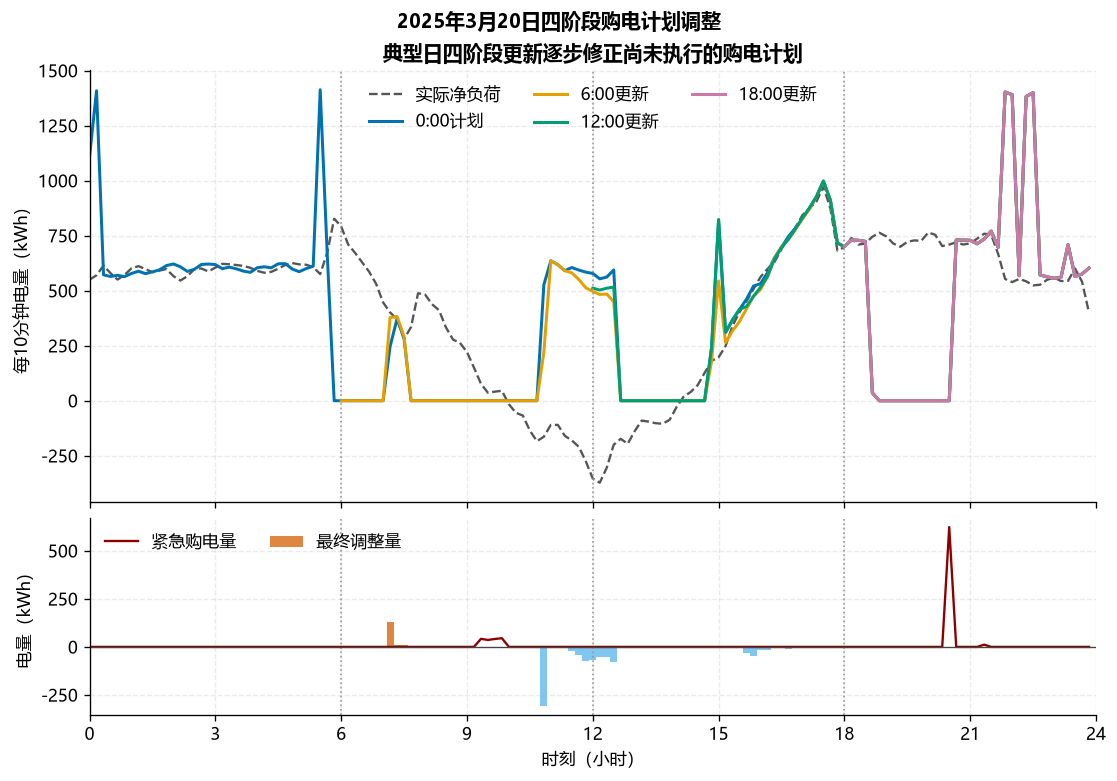

In [6]:
# 典型日四阶段调整轨迹：重放各决策时刻，保留每次更新后的剩余计划
def trace_four_stages(d, s0, A0, ALO, AHI):
    q = np.zeros(T)
    pred0 = point_forecast48(d, 0)
    target0 = pred0 + rho48(d, 0, A0)
    q[:] = solve_stage48(d, 0, target0, s0)
    qplan = q.copy(); current_target_day = target0[:T].copy()
    traces = {"0:00计划": q.copy()}
    for k in (1, 2, 3):
        t0 = STAGE_SLOT[k]; n_exec = T - t0
        pred = point_forecast48(d, k)
        lo = pred + rho48(d, k, ALO)
        hi = pred + rho48(d, k, AHI)
        base = current_target_day[t0:]
        if not np.all((base >= lo[:n_exec]) & (base <= hi[:n_exec])):
            target48 = pred + rho48(d, k, A0)
            target48[:n_exec] = np.clip(base, lo[:n_exec], hi[:n_exec])
            s_now = state_at(q, (L[d]-Gv[d])*DT, s0, t0)
            q[t0:] = solve_stage48(d, k, target48, s_now, qplan)
            current_target_day[t0:] = target48[:n_exec]
        traces[f"{ISSUE[k]}:00更新"] = q.copy()
    return traces

typical_date = pd.Timestamp("2025-03-20")
d = int(np.where(dates == typical_date)[0][0])
fi = d - START
traces = trace_four_stages(d, float(FIN["S0"][fi]), **PARAMS)
x = np.arange(T) / 6
actual_net = (L[d] - Gv[d]) * DT
colors = ["#0072B2", "#E69F00", "#009E73", "#CC79A7"]

fig, axes = plt.subplots(2, 1, figsize=(9.2, 6.4), sharex=True,
                         gridspec_kw={"height_ratios":[2.2,1]}, constrained_layout=True)
axes[0].plot(x, actual_net, color="#555555", ls="--", lw=1.4, label="实际净负荷")
for (label, arr), k, color in zip(traces.items(), range(4), colors):
    shown = arr.copy(); shown[:STAGE_SLOT[k]] = np.nan
    axes[0].plot(x, shown, color=color, lw=1.8, label=label)
for h in [6,12,18]:
    axes[0].axvline(h, color="#999999", ls=":", lw=1)
axes[0].set(title="典型日四阶段更新逐步修正尚未执行的购电计划", ylabel="每10分钟电量（kWh）")
axes[0].legend(ncol=3, frameon=False, loc="upper center")

delta = FIN["qadj"][fi] - FIN["qplan"][fi]
bar_colors = np.where(delta >= 0, "#D55E00", "#56B4E9")
axes[1].bar(x, delta, width=1/6, color=bar_colors, alpha=0.75, label="最终调整量")
axes[1].plot(x, FIN["e"][fi], color="#8B0000", lw=1.4, label="紧急购电量")
for h in [6,12,18]:
    axes[1].axvline(h, color="#999999", ls=":", lw=1)
axes[1].axhline(0, color="#444444", lw=0.8)
axes[1].set(xlabel="时刻（小时）", ylabel="电量（kWh）", xlim=(0,24), xticks=np.arange(0,25,3))
axes[1].legend(ncol=2, frameon=False)
fig.suptitle("2025年3月20日四阶段购电计划调整", fontsize=12, fontweight="bold")
fig.savefig(FIG_DIR / "问题三_典型日四阶段调整图.png", bbox_inches="tight", facecolor="white")
fig.savefig(FIG_DIR / "问题三_典型日四阶段调整图.svg", bbox_inches="tight", facecolor="white")
plt.show()


典型日图中的每条阶段曲线只从对应发布时间开始绘制，表示该阶段对尚未执行计划的更新；已经执行的历史时段不会被后验信息改写。下图同时给出最终调增、调减和紧急购电量，用于解释四阶段调整如何降低偏差成本。

## 8 是否需要引入其他时刻的预报

题目要求判断6:00、12:00和18:00预报是否有必要。这里使用相同的一月冻结参数、初始SOC和结算规则，比较问题三“仅0:00计划”与“四阶段方案”。

四阶段方案总费用为1314.95万元，仅0:00计划为1392.18万元，减少77.23万元。紧急购电费从143.86万元降至21.22万元，说明日内预报能够修正原计划中的预测偏差。

结论是：需要引入其他时刻的预报，但不能无条件调整。卡尔曼增益先衡量新预报可信度，不调整带再判断变化是否足以覆盖调整成本。当前实验评价三次日内信息的整体价值，不声称某一个调整时刻贡献最大。

In [7]:
# 信息边界与实现断言
assert len(SELECT_DAYS) == 21 and max(SELECT_DAYS) < START
assert point_forecast48(START, 3).shape == (288,)
assert rho48(START, 3, PARAMS["A0"]).shape == (288,)
# 18:00预报的后6小时落在次日，确认没有被自然日边界截断
release = START * T + STAGE_SLOT[3]
assert np.array_equal(np.arange(release, release + T)[-36:] // T,
                      np.full(36, START + 1))
# 费用和SOC基本可行性
assert np.all((FIN["S"] >= SMIN - 1e-6) & (FIN["S"] <= SMAX + 1e-6))
assert np.allclose(FIN["S0"][1:], FIN["S"][:-1, -1])
assert np.isfinite(summary.select_dtypes("number").to_numpy()).all()
print("验证通过：一月选参、完整跨日预报、严格48小时余量、SOC连续和费用动态生成。")

验证通过：一月选参、完整跨日预报、严格48小时余量、SOC连续和费用动态生成。


## 9 模型检验、优点与局限

### 9.1 模型检验

- 新增参数仅由1月1—10日预热、1月11—31日选择，2—12月不参与调参；
- 卡尔曼偏差、方差和增益只读取当前决策时刻前已经揭晓的误差；
- 四个阶段的输入均为288个10分钟时段，附件3跨日24小时预报不被截断；
- SOC上下界、跨日连续性、求解状态及费用对账均通过程序断言。

### 9.2 模型优点

1. 根据历史误差动态分配两类预测权重，避免固定依赖附件3或历史模型；
2. 完整使用附件3跨日预报，并在统一48小时框架中联合考虑调整费用与储能安排；
3. 不调整带能够抑制收益不足以覆盖成本的频繁调整；
4. 参数选择期和正式评价期严格分离，避免未来信息泄漏。

### 9.3 模型局限

1. 小区负荷没有日内更新，只能沿用问题二的历史预测；
2. 附件3从小时粒度插值为10分钟粒度，可能平滑短时波动；
3. 不调整带是单时段边际启发经一月验证得到的阶段级规则，不是含SOC动态耦合模型的全局闭式最优解；
4. 一月选择期较短，跨年度稳定性仍需新数据检验；
5. 当前实验评价三次日内信息的整体价值，尚未区分各发布时间的独立贡献。

## 10 指定日期结果

In [8]:
fd = dates[START:]
qp, qa, C_, U_, E_, S_, S0_ = (FIN[k] for k in ["qplan", "qadj", "c", "u", "e", "S", "S0"])
P = price[None, :]
fee = ((qp * P).sum(1) + (UP * P * np.maximum(qa-qp, 0)).sum(1)
       - (DN * P * np.maximum(qp-qa, 0)).sum(1) + (PEN * E_ * P).sum(1))
SPEC = pd.to_datetime(["2025-03-20", "2025-06-21", "2025-09-23", "2025-12-21"])
rows = []
for day in SPEC:
    i = int(np.where(fd == day)[0][0])
    rows.append({"日期": day.date(), "计划购电量/kWh": qp[i].sum(),
                 "调整后购电量/kWh": qa[i].sum(), "紧急购电量/kWh": E_[i].sum(),
                 "日初SOC/kWh": S0_[i], "日末SOC/kWh": S_[i,-1], "购电费/元": fee[i]})
display(pd.DataFrame(rows).set_index("日期"))

,计划购电量/kWh,调整后购电量/kWh,紧急购电量/kWh,日初SOC/kWh,日末SOC/kWh,购电费/元
日期,,,,,,
2025-03-20,61719.007694,61048.444684,799.412644,8827.306742,4640.428945,43150.382054
2025-06-21,39970.763042,40117.080146,0.000000,3725.085751,9415.464073,22259.657214
2025-09-23,68245.909309,67585.810552,241.795685,8641.601708,8651.405043,44249.471362
2025-12-21,95712.380867,96012.713469,48.612188,8831.693928,8699.044118,62103.151217


## 11 导出 `result3_filled.xlsx`

In [9]:
from openpyxl import load_workbook
wb = load_workbook(RESULT3_TEMPLATE)
fee_plan = (qp * P).sum(1)
fee_adj = fee_plan + (UP * P * np.maximum(qa-qp, 0)).sum(1) - (DN * P * np.maximum(qp-qa, 0)).sum(1)
for sheet, arr, fees in (("计划购电量", qp, fee_plan), ("调整购电量", qa, fee_adj)):
    ws = wb[sheet]
    for i in range(len(fd)):
        for j in range(T): ws.cell(i+2, j+2).value = float(max(arr[i,j], 0))
        ws.cell(i+2, T+2).value = float(arr[i].sum()); ws.cell(i+2, T+3).value = float(fees[i])
ws = wb["充放电量"]; ws.delete_rows(2, ws.max_row); row = 2
for i in range(len(fd)):
    for g in range(6):
        sl = slice(g*24, (g+1)*24)
        if g == 0:
            ws.cell(row,1).value = fd[i].strftime("%Y/%m/%d")
            ws.cell(row,5).value = "0:00"; ws.cell(row,6).value = float(S0_[i])
        elif g == 1:
            ws.cell(row,5).value = "24:00"; ws.cell(row,6).value = float(S_[i,-1])
        ws.cell(row,2).value = f"{g*4}:00-{(g+1)*4}:00"
        ws.cell(row,3).value = float(C_[i,sl].sum()); ws.cell(row,4).value = float(U_[i,sl].sum()); row += 1
ws = wb["紧急购电量"]; ws.delete_rows(2, ws.max_row); row = 2
for i in range(len(fd)):
    active = np.where(E_[i] > 1e-6)[0]
    for j in active:
        ws.cell(row,1).value = fd[i].strftime("%Y/%m/%d")
        ws.cell(row,2).value = f"{j*10//60}:{j*10%60:02d}-{(j+1)*10//60}:{(j+1)*10%60:02d}"
        ws.cell(row,3).value = float(E_[i,j]); row += 1
export_path = Path.cwd() / "result3_filled.xlsx"
wb.save(export_path)
print(f"已保存：{export_path}")

已保存：C:\Users\12055\Desktop\第三问预测+优化\result3_filled.xlsx


## 12 结论

问题三沿用问题二的预测、储能、机会约束和结算模型，新增卡尔曼预报融合、不调整带和三次日内调整。新增参数全部由一月选择，四个阶段均优化未来48小时。

卡尔曼滤波没有被删除：其偏差修正、误差方差、增益和融合预测均在第5节计算。第6节保留不调整带的边际推导，第8节直接回答是否需要其他时刻的预报。